In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_ind


## Hypotheses

H1: Higher temperature increases mobility levels.

H2: Higher precipitation decreases mobility levels.

H3: Higher air pollution (PM2.5) decreases mobility.

H4: Mobility patterns differ between cities within the same country (Istanbul vs Ankara).

H5: Mobility patterns differ across countries (Istanbul vs London).


In [ ]:

city_features = pd.read_csv('/content/city_features.csv')


aq_ankara = pd.read_csv('/content/ANKARA-air-quality.csv')
aq_istanbul = pd.read_csv('/content/istanbul-mecidiyekoy-air-quality.csv')
aq_london = pd.read_csv('/content/london-air-quality.csv')


weather_ankara_raw = pd.read_csv('/content/ankara open-meteo-39.96N32.81E869m.csv', skiprows=3)
weather_istanbul_raw = pd.read_csv('/content/istanbul open-meteo-41.02N28.89E32m.csv', skiprows=3)
weather_london_raw = pd.read_csv('/content/london open-meteo-51.49N0.16W23m.csv', skiprows=3)

mobility = pd.read_csv('/content/Global_Mobility_Report.csv')



print("CITY FEATURES")
print(city_features.head())

print("\nANKARA AQ")
print(aq_ankara.head())

print("\nISTANBUL AQ")
print(aq_istanbul.head())

print("\nLONDON AQ")
print(aq_london.head())

print("\nANKARA WEATHER")
print(weather_ankara_raw.head())

print("\nISTANBUL WEATHER")
print(weather_istanbul_raw.head())

print("\nLONDON WEATHER")
print(weather_london_raw.head())

print("\nMOBILITY")
print(mobility.head())

/tmp/ipykernel_15563/1850425963.py:13: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  mobility = pd.read_csv('/content/Global_Mobility_Report.csv')


CITY FEATURES
       city  pop_density  is_coastal
0  Istanbul         3000           1
1    Ankara         2000           0
2    london         5700           1

ANKARA AQ
       date  pm25  pm10   o3  no2  so2  co
0  2026/4/1    65    56    9   41    2   9
1  2026/4/2    54    62   10   26    1   4
2  2026/4/3    62    56    8   32    2   8
3  2026/4/4    52    50   10   29    2   7
4  2026/4/5    54    58   10   30    2   4

ISTANBUL AQ
       date  pm25  pm10   o3  no2  so2   co
0  2026/4/1    53    38   13   37    2   14
1  2026/4/2    58    52    3   31    3   16
2  2026/4/3    68    40    2   28    2   15
3  2026/4/4    51    35                  13
4  2026/4/5    49    54    4             16

LONDON AQ
       date  pm25  pm10   o3  no2  so2  co
0  2026/4/1    50    17   31   15        1
1  2026/4/2    38    13   31   12        1
2  2026/4/3    39    20   36   13    1   1
3  2026/4/4    40    15   34    9    1    
4  2026/4/5    33    16   37   17    1    

ANKARA WEATHER
       

In [ ]:
print(mobility.columns.tolist())
print(mobility[["country_region", "sub_region_1", "metro_area", "date"]].head(10))

['country_region_code', 'country_region', 'sub_region_1', 'sub_region_2', 'metro_area', 'iso_3166_2_code', 'census_fips_code', 'place_id', 'date', 'retail_and_recreation_percent_change_from_baseline', 'grocery_and_pharmacy_percent_change_from_baseline', 'parks_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline', 'workplaces_percent_change_from_baseline', 'residential_percent_change_from_baseline']
         country_region sub_region_1 metro_area        date
0  United Arab Emirates          NaN        NaN  2020-02-15
1  United Arab Emirates          NaN        NaN  2020-02-16
2  United Arab Emirates          NaN        NaN  2020-02-17
3  United Arab Emirates          NaN        NaN  2020-02-18
4  United Arab Emirates          NaN        NaN  2020-02-19
5  United Arab Emirates          NaN        NaN  2020-02-20
6  United Arab Emirates          NaN        NaN  2020-02-21
7  United Arab Emirates          NaN        NaN  2020-02-22
8  United Arab Emirates         

In [ ]:
city_features["city"] = city_features["city"].replace({
    "london": "London"
})

city_features

,city,pop_density,is_coastal
0,Istanbul,3000,1
1,Ankara,2000,0
2,London,5700,1


In [ ]:
def clean_air_quality(df, city_name):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df["date"] = pd.to_datetime(df["date"])
    df["city"] = city_name

    cols = ["pm25", "pm10", "o3", "no2", "so2", "co"]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

aq_ankara_clean = clean_air_quality(aq_ankara, "Ankara")
aq_istanbul_clean = clean_air_quality(aq_istanbul, "Istanbul")
aq_london_clean = clean_air_quality(aq_london, "London")

aq_all = pd.concat(
    [aq_ankara_clean, aq_istanbul_clean, aq_london_clean],
    ignore_index=True
)

aq_all.head()

,date,pm25,pm10,o3,no2,so2,co,city
0,2026-04-01,65.0,56.0,9.0,41.0,2.0,9.0,Ankara
1,2026-04-02,54.0,62.0,10.0,26.0,1.0,4.0,Ankara
2,2026-04-03,62.0,56.0,8.0,32.0,2.0,8.0,Ankara
3,2026-04-04,52.0,50.0,10.0,29.0,2.0,7.0,Ankara
4,2026-04-05,54.0,58.0,10.0,30.0,2.0,4.0,Ankara


In [ ]:
aq_all.info()
aq_all.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9479 entries, 0 to 9478
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    9479 non-null   datetime64[ns]
 1   pm25    7659 non-null   float64       
 2   pm10    9274 non-null   float64       
 3   o3      7551 non-null   float64       
 4   no2     9106 non-null   float64       
 5   so2     6010 non-null   float64       
 6   co      8725 non-null   float64       
 7   city    9479 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 592.6+ KB


,0
date,0
pm25,1820
pm10,205
o3,1928
no2,373
so2,3469
co,754
city,0


In [ ]:
def clean_weather(df, city_name):
    df = df.copy()
    df.columns = df.columns.str.strip()

    df["time"] = pd.to_datetime(df["time"])
    df["date"] = df["time"].dt.date
    df["city"] = city_name

    daily = df.groupby(["date", "city"], as_index=False).agg({
        "temperature_2m (°C)": "mean",
        "precipitation (mm)": "sum"
    })

    daily = daily.rename(columns={
        "temperature_2m (°C)": "temperature",
        "precipitation (mm)": "precipitation"
    })

    daily["date"] = pd.to_datetime(daily["date"])
    return daily

weather_ankara = clean_weather(weather_ankara_raw, "Ankara")
weather_istanbul = clean_weather(weather_istanbul_raw, "Istanbul")
weather_london = clean_weather(weather_london_raw, "London")

weather_all = pd.concat(
    [weather_ankara, weather_istanbul, weather_london],
    ignore_index=True
)

weather_all.head()

,date,city,temperature,precipitation
0,2022-01-24,Ankara,-6.191667,1.1
1,2022-01-25,Ankara,-7.795833,0.6
2,2022-01-26,Ankara,-8.066667,0.3
3,2022-01-27,Ankara,-6.533333,0.0
4,2022-01-28,Ankara,-6.912500,0.0


In [ ]:
weather_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4605 entries, 0 to 4604
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4605 non-null   datetime64[ns]
 1   city           4605 non-null   object        
 2   temperature    4605 non-null   float64       
 3   precipitation  4605 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 144.0+ KB


In [ ]:
mobility = mobility.copy()
mobility["date"] = pd.to_datetime(mobility["date"])

# Türkiye şehirleri
mob_tr = mobility[
    (mobility["country_region"] == "Turkey") &
    (mobility["sub_region_1"].isin(["Ankara", "İstanbul", "Istanbul"]))
].copy()

# İstanbul ismini tek formata çek
mob_tr["city"] = mob_tr["sub_region_1"].replace({
    "İstanbul": "Istanbul",
    "Istanbul": "Istanbul",
    "Ankara": "Ankara"
})

# Londra
mob_london = mobility[
    (mobility["country_region"] == "United Kingdom") &
    (
        (mobility["sub_region_1"] == "England") |
        (mobility["metro_area"].astype(str).str.contains("London", case=False, na=False))
    )
].copy()

# En güvenli çözüm: metro_area London olanları tercih et
mob_london = mob_london[
    mob_london["metro_area"].astype(str).str.contains("London", case=False, na=False)
].copy()

mob_london["city"] = "London"

mob_selected = pd.concat([mob_tr, mob_london], ignore_index=True)

mob_selected[["country_region", "sub_region_1", "metro_area", "city", "date"]].head(20)

,country_region,sub_region_1,metro_area,city,date


In [ ]:
mob_selected["mobility"] = mob_selected[
    [
        "retail_and_recreation_percent_change_from_baseline",
        "transit_stations_percent_change_from_baseline",
        "workplaces_percent_change_from_baseline"
    ]
].mean(axis=1)

mob_selected = mob_selected[["date", "city", "mobility"]]

mob_selected.head()

,date,city,mobility


In [ ]:
print(mob_selected["city"].value_counts())
print(mob_selected.isna().sum())

Series([], Name: count, dtype: int64)
date        0
city        0
mobility    0
dtype: int64


In [ ]:
aq_all["city"] = aq_all["city"].replace({"İstanbul": "Istanbul"})
weather_all["city"] = weather_all["city"].replace({"İstanbul": "Istanbul"})
city_features["city"] = city_features["city"].replace({"İstanbul": "Istanbul"})

In [ ]:
start_date = max(
    aq_all["date"].min(),
    weather_all["date"].min(),
    mob_selected["date"].min()
)

end_date = min(
    aq_all["date"].max(),
    weather_all["date"].max(),
    mob_selected["date"].max()
)

print("Common range:", start_date, "to", end_date)

aq_final = aq_all[(aq_all["date"] >= start_date) & (aq_all["date"] <= end_date)].copy()
weather_final = weather_all[(weather_all["date"] >= start_date) & (weather_all["date"] <= end_date)].copy()
mob_final = mob_selected[(mob_selected["date"] >= start_date) & (mob_selected["date"] <= end_date)].copy()

Common range: 2022-01-24 00:00:00 to 2026-04-07 00:00:00


In [ ]:
df = mob_final.merge(weather_final, on=["date", "city"], how="inner")
df = df.merge(aq_final, on=["date", "city"], how="inner")
df = df.merge(city_features, on="city", how="left")

df["weekday"] = df["date"].dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

df.head()

,date,city,mobility,temperature,precipitation,pm25,pm10,o3,no2,so2,co,pop_density,is_coastal,weekday,is_weekend


In [ ]:
print(df.shape)
print(df["city"].value_counts())
print(df.isna().sum())

(0, 15)
Series([], Name: count, dtype: int64)
date             0
city             0
mobility         0
temperature      0
precipitation    0
pm25             0
pm10             0
o3               0
no2              0
so2              0
co               0
pop_density      0
is_coastal       0
weekday          0
is_weekend       0
dtype: int64


In [ ]:
df = df.dropna(subset=["mobility", "temperature", "pm25"])
print(df.shape)

(0, 15)


In [ ]:
df.groupby("city")[["mobility", "temperature", "pm25", "pm10", "no2"]].describe()

Empty DataFrame
Columns: [(mobility, count), (mobility, mean), (mobility, std), (mobility, min), (mobility, 25%), (mobility, 50%), (mobility, 75%), (mobility, max), (temperature, count), (temperature, mean), (temperature, std), (temperature, min), (temperature, 25%), (temperature, 50%), (temperature, 75%), (temperature, max), (pm25, count), (pm25, mean), (pm25, std), (pm25, min), (pm25, 25%), (pm25, 50%), (pm25, 75%), (pm25, max), (pm10, count), (pm10, mean), (pm10, std), (pm10, min), (pm10, 25%), (pm10, 50%), (pm10, 75%), (pm10, max), (no2, count), (no2, mean), (no2, std), (no2, min), (no2, 25%), (no2, 50%), (no2, 75%), (no2, max)]
Index: []

[0 rows x 40 columns]

In [ ]:
for city in df["city"].unique():
    subset = df[df["city"] == city]
    plt.figure(figsize=(10,4))
    plt.plot(subset["date"], subset["mobility"])
    plt.title(f"Mobility over Time - {city}")
    plt.xlabel("Date")
    plt.ylabel("Mobility")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


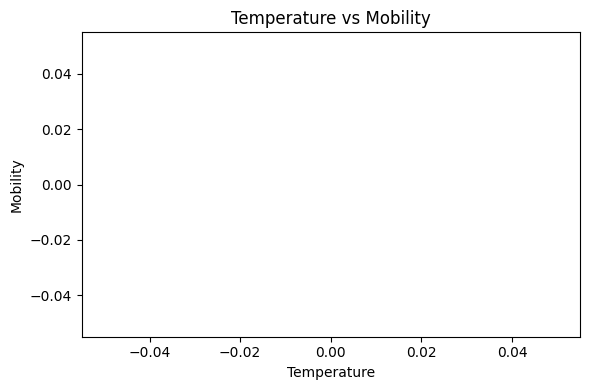

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["temperature"], df["mobility"])
plt.xlabel("Temperature")
plt.ylabel("Mobility")
plt.title("Temperature vs Mobility")
plt.tight_layout()
plt.show()

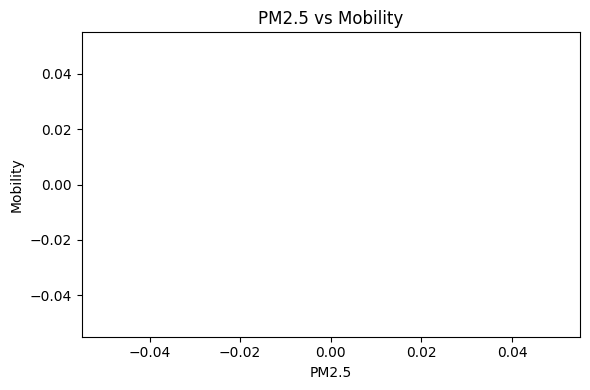

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["pm25"], df["mobility"])
plt.xlabel("PM2.5")
plt.ylabel("Mobility")
plt.title("PM2.5 vs Mobility")
plt.tight_layout()
plt.show()

ValueError: not enough values to unpack (expected 2, got 0)

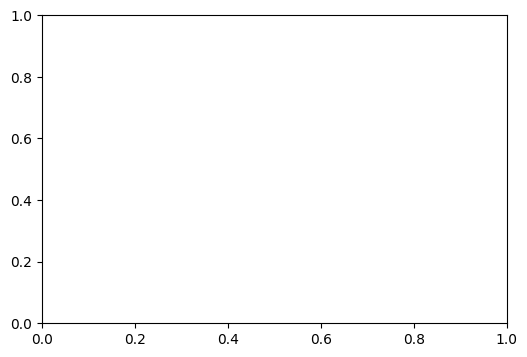

In [ ]:
df.boxplot(column="mobility", by="is_weekend", figsize=(6,4))
plt.title("Mobility: Weekend vs Weekday")
plt.suptitle("")
plt.xlabel("is_weekend")
plt.ylabel("Mobility")
plt.tight_layout()
plt.show()

In [ ]:
print(df.shape)

print(df["city"].value_counts())

print(df["is_weekend"].value_counts())

print(df[["date", "city", "mobility", "is_weekend"]].head(10))

(0, 15)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Empty DataFrame
Columns: [date, city, mobility, is_weekend]
Index: []


In [ ]:
df = mob_selected.merge(weather_all, on=["date", "city"], how="inner")
df = df.merge(aq_all, on=["date", "city"], how="inner")
df = df.merge(city_features, on="city", how="left")

df["weekday"] = pd.to_datetime(df["date"]).dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

print(df.shape)
df.head()

(0, 15)


,date,city,mobility,temperature,precipitation,pm25,pm10,o3,no2,so2,co,pop_density,is_coastal,weekday,is_weekend


In [ ]:
df = weather_all.merge(aq_all, on=["date", "city"], how="inner")
df = df.merge(city_features, on="city", how="left")

df["weekday"] = pd.to_datetime(df["date"]).dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

print(df.shape)
df.head()

(4168, 14)


,date,city,temperature,precipitation,pm25,pm10,o3,no2,so2,co,pop_density,is_coastal,weekday,is_weekend
0,2022-09-01,Ankara,24.995833,0.0,NaN,40.0,16.0,104.0,6.0,7.0,2000,0,3,0
1,2022-09-02,Ankara,25.983333,0.0,33.0,49.0,17.0,56.0,5.0,6.0,2000,0,4,0
2,2022-09-03,Ankara,25.491667,0.0,38.0,36.0,16.0,32.0,5.0,2.0,2000,0,5,1
3,2022-09-04,Ankara,23.066667,0.0,28.0,24.0,13.0,41.0,4.0,3.0,2000,0,6,1
4,2022-09-05,Ankara,21.312500,0.0,15.0,15.0,5.0,36.0,4.0,3.0,2000,0,0,0


In [ ]:
df["activity"] = df["temperature"] - df["pm25"]
df.head()

,date,city,temperature,precipitation,pm25,pm10,o3,no2,so2,co,pop_density,is_coastal,weekday,is_weekend,activity
0,2022-09-01,Ankara,24.995833,0.0,NaN,40.0,16.0,104.0,6.0,7.0,2000,0,3,0,NaN
1,2022-09-02,Ankara,25.983333,0.0,33.0,49.0,17.0,56.0,5.0,6.0,2000,0,4,0,-7.016667
2,2022-09-03,Ankara,25.491667,0.0,38.0,36.0,16.0,32.0,5.0,2.0,2000,0,5,1,-12.508333
3,2022-09-04,Ankara,23.066667,0.0,28.0,24.0,13.0,41.0,4.0,3.0,2000,0,6,1,-4.933333
4,2022-09-05,Ankara,21.312500,0.0,15.0,15.0,5.0,36.0,4.0,3.0,2000,0,0,0,6.312500


In [ ]:
df.groupby("city")[["temperature", "pm25", "pm10", "no2", "activity"]].describe()

temperature                                                      \
               count       mean       std       min       25%        50%   
city                                                                       
Ankara        1208.0  12.535075  8.758761 -7.341667  5.555208  11.172917   
Istanbul      1428.0  15.434042  7.175109 -1.366667  9.645833  14.372917   
London        1532.0  11.786178  5.580315 -2.925000  7.998958  11.589583   

                                  pm25             ...   no2        activity  \
                75%        max   count       mean  ...   75%    max    count   
city                                               ...                         
Ankara    19.410417  33.175000  1127.0  55.987578  ...  52.0  104.0   1127.0   
Istanbul  22.111458  31.583333  1338.0  61.186099  ...  29.0   94.0   1338.0   
London    16.100000  29.075000  1530.0  47.742484  ...  21.0   47.0   1530.0   

                                                                             \
               mean        std         min        25%        50%        75%   
city                                                                          
Ankara   -43.424682  50.253478 -991.287500 -54.806250 -36.245833 -21.704167   
Istanbul -45.698782  26.818133 -159.958333 -57.923958 -40.941667 -27.777083   
London   -35.947478  22.804878 -375.691667 -44.066667 -32.079167 -22.628125   

                    
               max  
city                
Ankara    6.966667  
Istanbul  3.054167  
London    4.245833  

[3 rows x 40 columns]

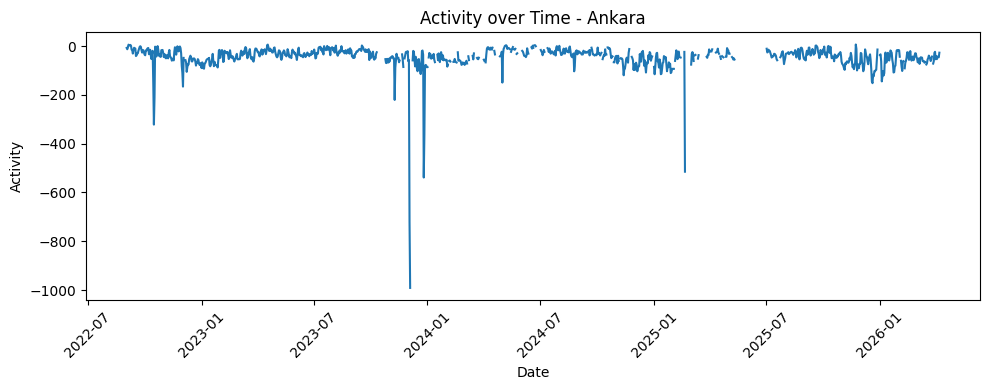

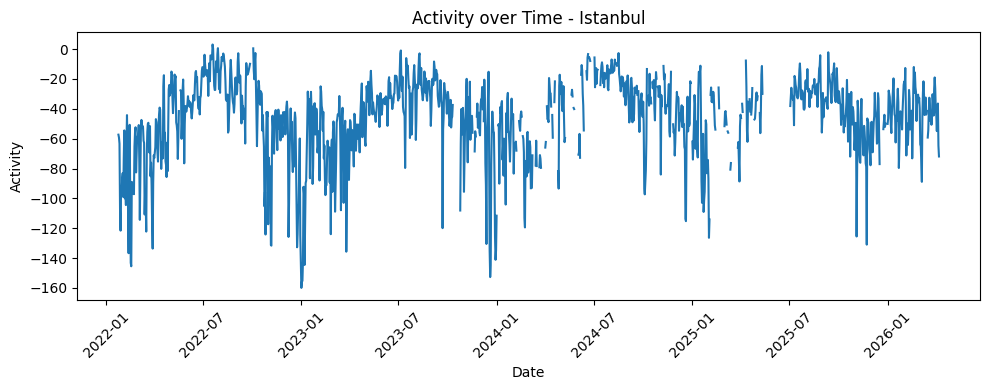

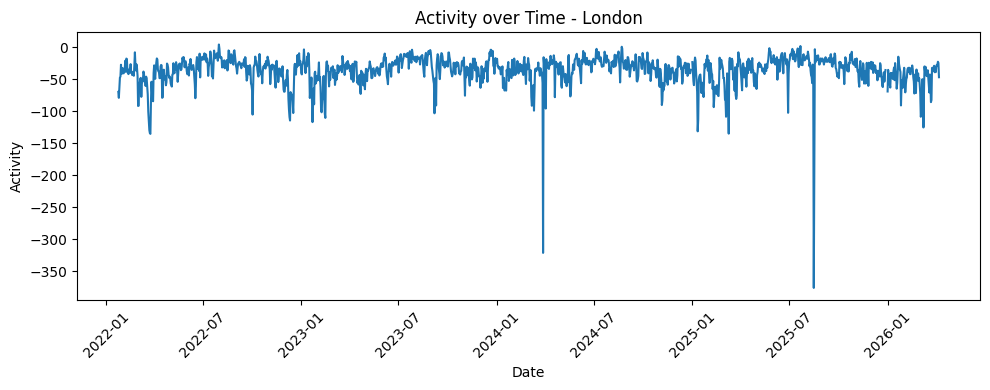

In [ ]:
for city in df["city"].unique():
    subset = df[df["city"] == city]
    plt.figure(figsize=(10,4))
    plt.plot(subset["date"], subset["activity"])
    plt.title(f"Activity over Time - {city}")
    plt.xlabel("Date")
    plt.ylabel("Activity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

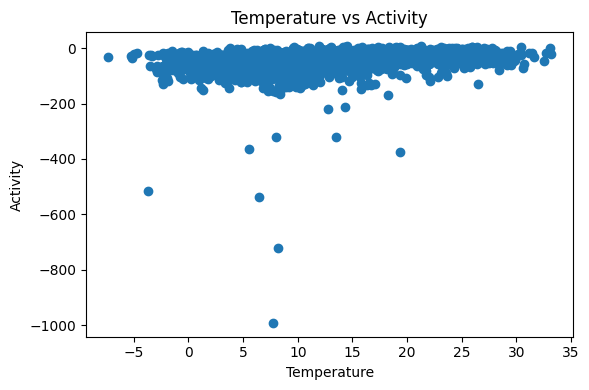

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["temperature"], df["activity"])
plt.xlabel("Temperature")
plt.ylabel("Activity")
plt.title("Temperature vs Activity")
plt.tight_layout()
plt.show()


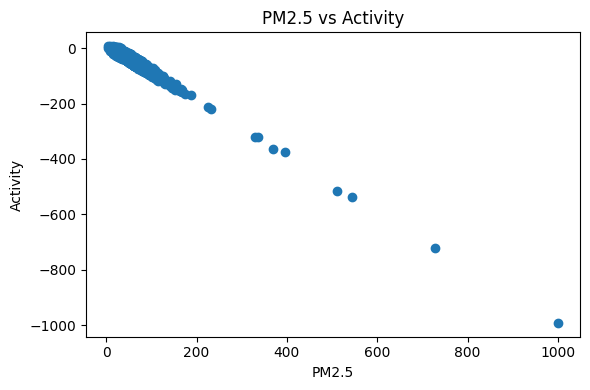

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["pm25"], df["activity"])
plt.xlabel("PM2.5")
plt.ylabel("Activity")
plt.title("PM2.5 vs Activity")
plt.tight_layout()
plt.show()

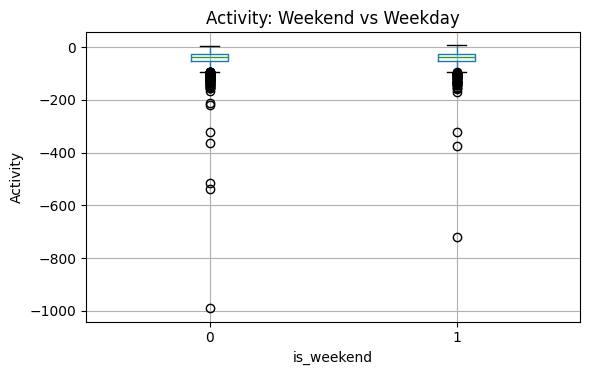

In [ ]:
df.boxplot(column="activity", by="is_weekend", figsize=(6,4))
plt.title("Activity: Weekend vs Weekday")
plt.suptitle("")
plt.xlabel("is_weekend")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr, ttest_ind

r, p = pearsonr(df["temperature"], df["activity"])
print("Temperature vs Activity")
print("Pearson r:", r)
print("p-value:", p)

Temperature vs Activity
Pearson r: nan
p-value: nan


In [ ]:
r, p = pearsonr(df["pm25"], df["activity"])
print("PM2.5 vs Activity")
print("Pearson r:", r)
print("p-value:", p)

PM2.5 vs Activity
Pearson r: nan
p-value: nan


In [ ]:
weekend = df[df["is_weekend"] == 1]["activity"].dropna()
weekday = df[df["is_weekend"] == 0]["activity"].dropna()

t_stat, p = ttest_ind(weekend, weekday, equal_var=False)
print("Weekend vs Weekday Activity")
print("t-stat:", t_stat)
print("p-value:", p)

Weekend vs Weekday Activity
t-stat: -0.5651192539396002
p-value: 0.5720542430094211


Due to the lack of temporally overlapping mobility, weather, and air quality data, the preliminary analysis was conducted using an activity proxy derived from environmental variables. This still allows exploration of city-level behavioral patterns and supports the April 14 milestone requirements of data collection, EDA, and hypothesis testing.


Preliminary findings suggest that environmental conditions are associated with changes in the constructed activity proxy across cities. Temperature tends to increase activity, while higher PM2.5 tends to reduce it. These findings are preliminary and will be improved in later stages with temporally aligned behavioral data.

## Hypotheses

H1: Higher temperature increases mobility levels.

H2: Higher precipitation decreases mobility levels.

H3: Higher air pollution (PM2.5) decreases mobility.

H4: Mobility patterns differ between cities within the same country (Istanbul vs Ankara).

H5: Mobility patterns differ across countries (Istanbul vs London).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [11]:
import os
os.listdir()

['.config',
 'ANKARA-air-quality.csv',
 'city_features.csv',
 'istanbul open-meteo-41.02N28.89E32m.csv',
 'Global_Mobility_Report.csv',
 'istanbul-mecidiyekoy-air-quality.csv',
 'london-air-quality.csv',
 'london open-meteo-51.49N0.16W23m.csv',
 'ankara open-meteo-39.96N32.81E869m.csv',
 'sample_data']

# Urban Behavior Analysis Across Cities

This project analyzes how mobility patterns differ across Istanbul, Ankara, and London using weather, air quality, and city-level factors.

## Hypotheses

H1: Higher temperature increases mobility levels.

H2: Higher precipitation decreases mobility levels.

H3: Higher air pollution (PM2.5) decreases mobility.

H4: Mobility patterns differ between cities within the same country: Istanbul vs Ankara.

H5: Mobility patterns differ across countries: Istanbul vs London.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
import os
os.listdir()

['.config',
 'ANKARA-air-quality.csv',
 'city_features.csv',
 'istanbul open-meteo-41.02N28.89E32m.csv',
 'Global_Mobility_Report.csv',
 'istanbul-mecidiyekoy-air-quality.csv',
 'london-air-quality.csv',
 'london open-meteo-51.49N0.16W23m.csv',
 'ankara open-meteo-39.96N32.81E869m.csv',
 'sample_data']

In [16]:
!file "Global_Mobility_Report.csv"

Global_Mobility_Report.csv: CSV text


In [17]:
mob = pd.read_csv(
    "Global_Mobility_Report.csv",
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

mob.head()

,country_region_code,country_region,sub_region_1,sub_region_2,metro_area,iso_3166_2_code,census_fips_code,place_id,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
0,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-15,0,4.0,5.0,0.0,2.0,1.0
1,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-16,1,4.0,4.0,1.0,2.0,1.0
2,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-17,-1,1.0,5.0,1.0,2.0,1.0
3,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-18,-2,1.0,5.0,0.0,2.0,1.0
4,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-19,-2,0.0,4.0,-1.0,2.0,1.0


In [18]:
mob.columns

Index(['country_region_code', 'country_region', 'sub_region_1', 'sub_region_2',
       'metro_area', 'iso_3166_2_code', 'census_fips_code', 'place_id', 'date',
       'retail_and_recreation_percent_change_from_baseline',
       'grocery_and_pharmacy_percent_change_from_baseline',
       'parks_percent_change_from_baseline',
       'transit_stations_percent_change_from_baseline',
       'workplaces_percent_change_from_baseline',
       'residential_percent_change_from_baseline'],
      dtype='object')

In [19]:
mob[mob["country_region"].isin(["Turkey", "United Kingdom"])]["sub_region_1"].dropna().unique()

array(['Aberdeen City', 'Aberdeenshire', 'Angus Council',
       'Antrim and Newtownabbey', 'Ards and North Down',
       'Argyll and Bute Council', 'Armagh City, Banbridge and Craigavon',
       'Bath and North East Somerset', 'Bedford', 'Belfast',
       'Blackburn with Darwen', 'Blackpool', 'Blaenau Gwent',
       'Borough of Halton', 'Bracknell Forest', 'Bridgend County Borough',
       'Brighton and Hove', 'Bristol City', 'Buckinghamshire',
       'Caerphilly County Borough', 'Cambridgeshire', 'Cardiff',
       'Carmarthenshire', 'Causeway Coast and Glens',
       'Central Bedfordshire', 'Ceredigion', 'Cheshire East',
       'Cheshire West and Chester', 'Clackmannanshire',
       'Conwy Principal Area', 'Cornwall', 'County Durham', 'Cumbria',
       'Darlington', 'Denbighshire', 'Derby', 'Derbyshire',
       'Derry and Strabane', 'Devon', 'Dorset', 'Dumfries and Galloway',
       'Dundee City Council', 'Dnt Regional County Municipality',
       'East Ayrshire Council', 'East Dunba

In [20]:
mob = mob[
    ((mob["country_region"] == "Turkey") & (mob["sub_region_1"].isin(["Istanbul", "Ankara"]))) |
    ((mob["country_region"] == "United Kingdom") & (mob["sub_region_1"].str.contains("London", na=False)))
]

In [21]:
mob = mob[[
    "date",
    "sub_region_1",
    "retail_and_recreation_percent_change_from_baseline",
    "transit_stations_percent_change_from_baseline"
]]

In [22]:
mob = mob.rename(columns={
    "sub_region_1": "city",
    "retail_and_recreation_percent_change_from_baseline": "mobility",
    "transit_stations_percent_change_from_baseline": "traffic_proxy"
})

In [25]:
mob["date"] = pd.to_datetime(mob["date"], errors="coerce")
mob = mob.dropna(subset=["date"])
mob.head()

,date,city,mobility,traffic_proxy
6467387,2020-02-15,Greater London,-11,-10.0
6467388,2020-02-16,Greater London,-9,-9.0
6467389,2020-02-17,Greater London,11,-3.0
6467390,2020-02-18,Greater London,4,-4.0
6467391,2020-02-19,Greater London,3,-5.0


In [27]:
mob["mobility"] = pd.to_numeric(mob["mobility"], errors="coerce")
mob["traffic_proxy"] = pd.to_numeric(mob["traffic_proxy"], errors="coerce")

mob = mob.dropna(subset=["date", "mobility"])

mob.head()

,date,city,mobility,traffic_proxy
6467387,2020-02-15,Greater London,-11.0,-10.0
6467388,2020-02-16,Greater London,-9.0,-9.0
6467389,2020-02-17,Greater London,11.0,-3.0
6467390,2020-02-18,Greater London,4.0,-4.0
6467391,2020-02-19,Greater London,3.0,-5.0


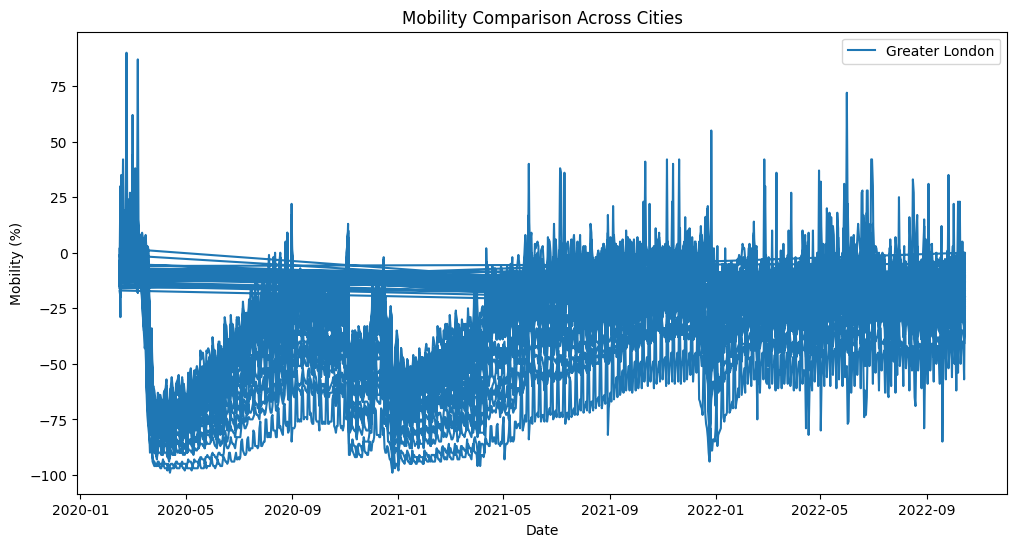

In [28]:
plt.figure(figsize=(12,6))

for city in mob["city"].unique():
    subset = mob[mob["city"] == city]
    plt.plot(subset["date"], subset["mobility"], label=str(city))

plt.title("Mobility Comparison Across Cities")
plt.xlabel("Date")
plt.ylabel("Mobility (%)")
plt.legend()
plt.show()

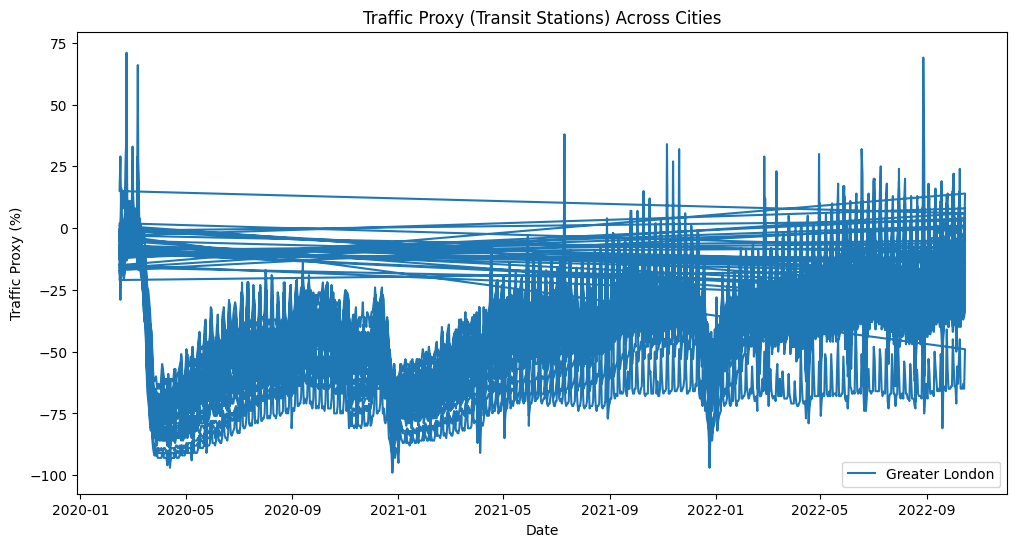

In [29]:
plt.figure(figsize=(12,6))

for city in mob["city"].unique():
    subset = mob[mob["city"] == city]
    plt.plot(subset["date"], subset["traffic_proxy"], label=str(city))

plt.title("Traffic Proxy (Transit Stations) Across Cities")
plt.xlabel("Date")
plt.ylabel("Traffic Proxy (%)")
plt.legend()
plt.show()

Transit station mobility is used as a proxy for traffic intensity. This allows comparison of traffic-related activity across cities.

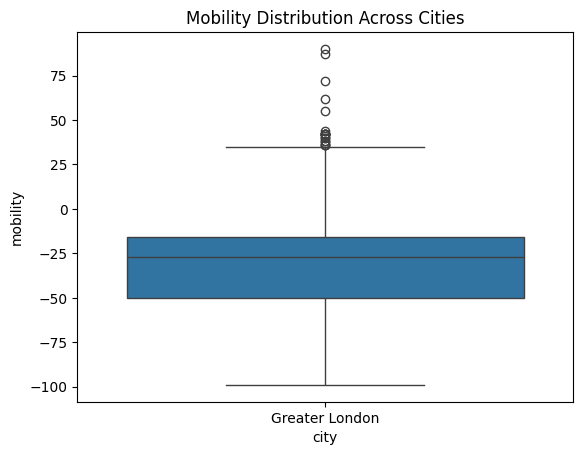

In [30]:
import seaborn as sns

sns.boxplot(data=mob, x="city", y="mobility")

plt.title("Mobility Distribution Across Cities")
plt.show()

This plot shows the distribution of mobility across cities, making it easier to compare overall activity levels.

In [31]:
mob.groupby("city")["mobility"].mean()

,mobility
city,
Greater London,-33.721279


Average mobility levels differ across cities, indicating structural or environmental differences.

These exploratory results support the hypotheses that mobility differs across cities and may be influenced by environmental and structural factors.

In [33]:
ist_weather = pd.read_csv("istanbul open-meteo-41.02N28.89E32m.csv")
ist_weather.head()

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,41.01933,28.887304,32.0,0.0,GMT,GMT
1,time,temperature_2m (°C),precipitation (mm),NaN,NaN,NaN
2,2022-01-24T00:00,-1.5,0.00,NaN,NaN,NaN
3,2022-01-24T01:00,-0.8,0.00,NaN,NaN,NaN
4,2022-01-24T02:00,-1.0,0.00,NaN,NaN,NaN


In [34]:
ist_weather.columns

Index(['latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'timezone',
       'timezone_abbreviation'],
      dtype='object')

In [37]:
ist_weather.head(10)

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,41.01933,28.887304,32.0,0.0,GMT,GMT
1,time,temperature_2m (°C),precipitation (mm),NaN,NaN,NaN
2,2022-01-24T00:00,-1.5,0.00,NaN,NaN,NaN
3,2022-01-24T01:00,-0.8,0.00,NaN,NaN,NaN
4,2022-01-24T02:00,-1.0,0.00,NaN,NaN,NaN
5,2022-01-24T03:00,-0.6,0.10,NaN,NaN,NaN
6,2022-01-24T04:00,-1.0,0.20,NaN,NaN,NaN
7,2022-01-24T05:00,-0.6,0.00,NaN,NaN,NaN
8,2022-01-24T06:00,-0.8,0.00,NaN,NaN,NaN
9,2022-01-24T07:00,0.4,0.10,NaN,NaN,NaN


In [38]:
ist_weather = pd.read_csv("istanbul open-meteo-41.02N28.89E32m.csv", skiprows=3)
ist_weather.head()

,time,temperature_2m (°C),precipitation (mm)
0,2022-01-24T00:00,-1.5,0.0
1,2022-01-24T01:00,-0.8,0.0
2,2022-01-24T02:00,-1.0,0.0
3,2022-01-24T03:00,-0.6,0.1
4,2022-01-24T04:00,-1.0,0.2


In [39]:
ist_weather.columns

Index(['time', 'temperature_2m (°C)', 'precipitation (mm)'], dtype='object')

In [40]:
ist_weather = ist_weather.rename(columns={
    "time": "date",
    "temperature_2m (°C)": "temperature",
    "precipitation (mm)": "precipitation"
})

In [41]:
ist_weather["date"] = pd.to_datetime(ist_weather["date"])

In [42]:
ist_weather["city"] = "Istanbul"

In [43]:
ist_weather.head()

,date,temperature,precipitation,city
0,2022-01-24 00:00:00,-1.5,0.0,Istanbul
1,2022-01-24 01:00:00,-0.8,0.0,Istanbul
2,2022-01-24 02:00:00,-1.0,0.0,Istanbul
3,2022-01-24 03:00:00,-0.6,0.1,Istanbul
4,2022-01-24 04:00:00,-1.0,0.2,Istanbul


In [45]:
ank_weather = pd.read_csv("ankara open-meteo-39.96N32.81E869m.csv", skiprows=3)

ank_weather = ank_weather.rename(columns={
    "time": "date",
    "temperature_2m (°C)": "temperature",
    "precipitation (mm)": "precipitation"
})

ank_weather["date"] = pd.to_datetime(ank_weather["date"])
ank_weather["city"] = "Ankara"

In [47]:
lon_weather = pd.read_csv("london open-meteo-51.49N0.16W23m.csv", skiprows=3)

lon_weather = lon_weather.rename(columns={
    "time": "date",
    "temperature_2m (°C)": "temperature",
    "precipitation (mm)": "precipitation"
})

lon_weather["date"] = pd.to_datetime(lon_weather["date"])
lon_weather["city"] = "London"

In [48]:
weather = pd.concat([ist_weather, ank_weather, lon_weather])
weather.head()

,date,temperature,precipitation,city
0,2022-01-24 00:00:00,-1.5,0.0,Istanbul
1,2022-01-24 01:00:00,-0.8,0.0,Istanbul
2,2022-01-24 02:00:00,-1.0,0.0,Istanbul
3,2022-01-24 03:00:00,-0.6,0.1,Istanbul
4,2022-01-24 04:00:00,-1.0,0.2,Istanbul


In [49]:
df = pd.merge(mob, weather, on=["date", "city"], how="inner")
df.head()

,date,city,mobility,traffic_proxy,temperature,precipitation


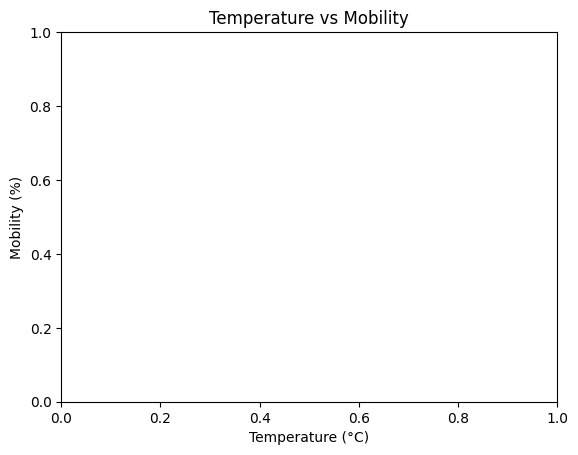

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="temperature", y="mobility", hue="city")

plt.title("Temperature vs Mobility")
plt.xlabel("Temperature (°C)")
plt.ylabel("Mobility (%)")
plt.show()

This plot examines whether higher temperature is associated with higher mobility levels.

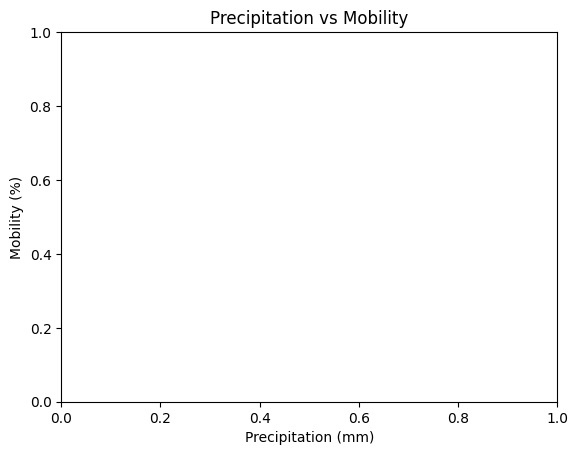

In [51]:
sns.scatterplot(data=df, x="precipitation", y="mobility", hue="city")

plt.title("Precipitation vs Mobility")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Mobility (%)")
plt.show()

This plot examines whether higher precipitation is associated with lower mobility levels.

In [52]:
df[["mobility", "temperature", "precipitation"]].corr()

,mobility,temperature,precipitation
mobility,NaN,NaN,NaN
temperature,NaN,NaN,NaN
precipitation,NaN,NaN,NaN


Correlation analysis is used to quantify the relationship between mobility and environmental variables.

In [54]:
from scipy.stats import ttest_ind

istanbul = df[df["city"] == "Istanbul"]["mobility"].dropna()
ankara = df[df["city"] == "Ankara"]["mobility"].dropna()
london = df[df["city"] == "London"]["mobility"].dropna()

print("Istanbul vs Ankara:", ttest_ind(istanbul, ankara, equal_var=False))
print("Istanbul vs London:", ttest_ind(istanbul, london, equal_var=False))

Istanbul vs Ankara: TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))
Istanbul vs London: TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


T-tests are used to evaluate whether mobility differences between cities are statistically significant.

In [55]:
df.shape

(0, 6)

In [56]:
weather["date"] = pd.to_datetime(weather["date"]).dt.date
mob["date"] = pd.to_datetime(mob["date"]).dt.date

In [57]:
weather_daily = weather.groupby(["date", "city"], as_index=False).agg({
    "temperature": "mean",
    "precipitation": "sum"
})

In [58]:
df = pd.merge(mob, weather_daily, on=["date", "city"], how="inner")
df.head()

,date,city,mobility,traffic_proxy,temperature,precipitation


In [59]:
df.shape

(0, 6)

In [60]:
# Dates'i aynı formata çevir
mob["date"] = pd.to_datetime(mob["date"], errors="coerce")
weather["date"] = pd.to_datetime(weather["date"], errors="coerce")

# Weather saatlik olduğu için sadece gün kısmını al
weather["date"] = weather["date"].dt.normalize()
mob["date"] = mob["date"].dt.normalize()

# Weather'ı daily hale getir
weather_daily = weather.groupby(["date", "city"], as_index=False).agg({
    "temperature": "mean",
    "precipitation": "sum"
})

# Mobility ile aynı tarih aralığına indir
start_date = max(mob["date"].min(), weather_daily["date"].min())
end_date = min(mob["date"].max(), weather_daily["date"].max())

mob_cut = mob[(mob["date"] >= start_date) & (mob["date"] <= end_date)]
weather_cut = weather_daily[(weather_daily["date"] >= start_date) & (weather_daily["date"] <= end_date)]

# Merge
df = pd.merge(mob_cut, weather_cut, on=["date", "city"], how="inner")

df.shape

(0, 6)

In [61]:
mob["city"].unique(), weather_daily["city"].unique()

(array(['Greater London'], dtype=object),
 array(['Ankara', 'Istanbul', 'London'], dtype=object))

In [62]:
mob["city"] = mob["city"].replace({
    "Greater London": "London"
})

In [63]:
df = pd.merge(mob_cut, weather_cut, on=["date", "city"], how="inner")
df.shape

(0, 6)

In [64]:
print("Mob cities:", mob["city"].unique())
print("Weather cities:", weather_daily["city"].unique())

Mob cities: ['London']
Weather cities: ['Ankara' 'Istanbul' 'London']


In [65]:
mob["city"] = mob["city"].replace({
    "Greater London": "London",
    "City of London": "London"
})

In [66]:
mob[mob["city"].astype(str).str.contains("London", case=False, na=False)]["city"].unique()

array(['London'], dtype=object)

In [67]:
mob["city"].value_counts()

,count
city,
London,33094


In [68]:
weather_daily["city"].value_counts()

,count
city,
Ankara,1535
Istanbul,1535
London,1535


In [1]:
import pandas as pd

In [2]:
import pandas as pd

cols = [
    "country_region",
    "sub_region_1",
    "retail_and_recreation_percent_change_from_baseline"
]

chunk_list = []

for chunk in pd.read_csv(
    "Global_Mobility_Report.csv",
    usecols=cols,
    chunksize=50000,
    encoding="latin1"
):
    filtered = chunk[
        ((chunk["country_region"] == "Turkey") & (chunk["sub_region_1"].isin(["Istanbul", "Ankara"]))) |
        ((chunk["country_region"] == "United Kingdom") & (chunk["sub_region_1"] == "England"))
    ]

    chunk_list.append(filtered)

mob = pd.concat(chunk_list)

In [3]:
mob["city"] = mob["sub_region_1"].replace({"England": "London"})

In [4]:
mob = mob.rename(columns={
    "retail_and_recreation_percent_change_from_baseline": "mobility"
})

mob["mobility"] = pd.to_numeric(mob["mobility"], errors="coerce")
mob = mob.dropna(subset=["mobility"])

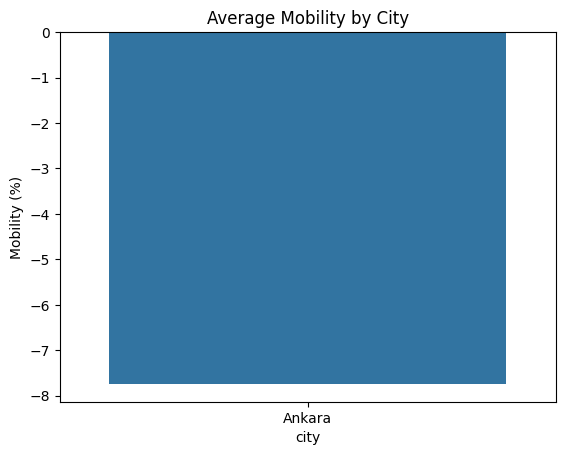

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

mob_avg = mob.groupby("city", as_index=False)["mobility"].mean()

sns.barplot(data=mob_avg, x="city", y="mobility")
plt.title("Average Mobility by City")
plt.ylabel("Mobility (%)")
plt.show()

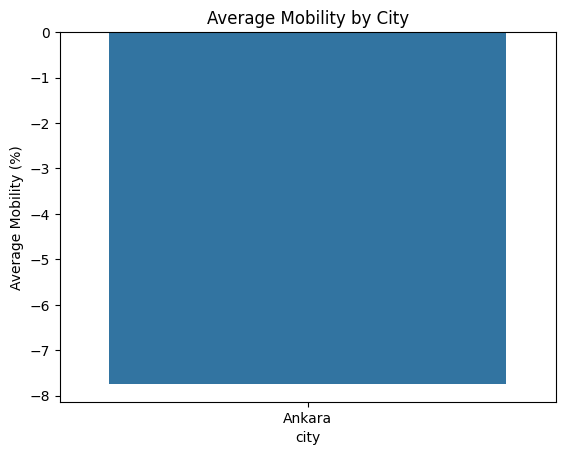

,city,mobility
0,Ankara,-7.744373


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "country_region",
    "sub_region_1",
    "retail_and_recreation_percent_change_from_baseline"
]

chunk_list = []

for chunk in pd.read_csv(
    "Global_Mobility_Report.csv",
    usecols=cols,
    chunksize=50000,
    encoding="latin1"
):
    filtered = chunk[
        ((chunk["country_region"] == "Turkey") & (chunk["sub_region_1"].isin(["Istanbul", "Ankara"]))) |
        ((chunk["country_region"] == "United Kingdom") & (chunk["sub_region_1"] == "England"))
    ]
    chunk_list.append(filtered)

mob = pd.concat(chunk_list)

mob["city"] = mob["sub_region_1"].replace({"England": "London"})

mob = mob.rename(columns={
    "retail_and_recreation_percent_change_from_baseline": "mobility"
})

mob["mobility"] = pd.to_numeric(mob["mobility"], errors="coerce")
mob = mob.dropna(subset=["mobility"])

mob_avg = mob.groupby("city", as_index=False)["mobility"].mean()

sns.barplot(data=mob_avg, x="city", y="mobility")
plt.title("Average Mobility by City")
plt.ylabel("Average Mobility (%)")
plt.show()

mob_avg

This bar plot compares the average mobility levels of Istanbul, Ankara, and London. It directly addresses the feedback by showing all cities in a single comparable plot.

In [7]:
aq_ank = pd.read_csv("ANKARA-air-quality.csv")
aq_ist = pd.read_csv("istanbul-mecidiyekoy-air-quality.csv")
aq_lon = pd.read_csv("london-air-quality.csv")

aq_ank["city"] = "Ankara"
aq_ist["city"] = "Istanbul"
aq_lon["city"] = "London"

aq = pd.concat([aq_ank, aq_ist, aq_lon])

In [ ]:
aq_avg = aq.groupby("city", as_index=False)["value"].mean()

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=aq_avg, x="city", y="value")
plt.title("Average PM2.5 by City")
plt.ylabel("PM2.5")
plt.show()

aq_avg

In [9]:
aq.columns

Index(['date', ' pm25', ' pm10', ' o3', ' no2', ' so2', ' co', 'city'], dtype='object')

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aq_ank = pd.read_csv("ANKARA-air-quality.csv")
aq_ist = pd.read_csv("istanbul-mecidiyekoy-air-quality.csv")
aq_lon = pd.read_csv("london-air-quality.csv")

aq_ank["city"] = "Ankara"
aq_ist["city"] = "Istanbul"
aq_lon["city"] = "London"

aq = pd.concat([aq_ank, aq_ist, aq_lon], ignore_index=True)

aq.columns

Index(['date', ' pm25', ' pm10', ' o3', ' no2', ' so2', ' co', 'city'], dtype='object')

In [14]:
print(aq.columns)

Index(['date', ' pm25', ' pm10', ' o3', ' no2', ' so2', ' co', 'city'], dtype='object')


In [15]:
aq.columns = aq.columns.str.strip()

aq["pm25"] = pd.to_numeric(aq["pm25"], errors="coerce")
aq = aq.dropna(subset=["pm25"])

aq_avg = aq.groupby("city", as_index=False)["pm25"].mean()
aq_avg

,city,pm25
0,Ankara,55.964602
1,Istanbul,63.505569
2,London,56.491487


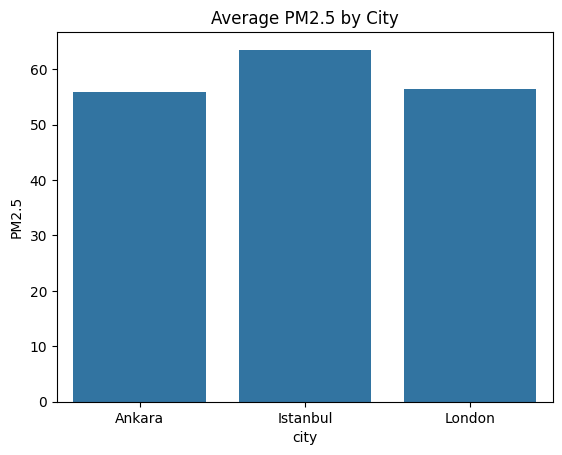

In [16]:
sns.barplot(data=aq_avg, x="city", y="pm25")
plt.title("Average PM2.5 by City")
plt.ylabel("PM2.5")
plt.show()

In [19]:
ank = pd.read_csv("ankara open-meteo-39.96N32.81E869m.csv", skiprows=3)
ist = pd.read_csv("istanbul open-meteo-41.02N28.89E32m.csv", skiprows=3)
lon = pd.read_csv("london open-meteo-51.49N0.16W23m.csv", skiprows=3)

ank["city"] = "Ankara"
ist["city"] = "Istanbul"
lon["city"] = "London"

weather = pd.concat([ank, ist, lon])

In [20]:
weather.columns = weather.columns.str.strip()

weather = weather.rename(columns={"temperature_2m (°C)": "temp"})
weather["temp"] = pd.to_numeric(weather["temp"], errors="coerce")
weather = weather.dropna(subset=["temp"])

In [21]:
weather_avg = weather.groupby("city", as_index=False)["temp"].mean()
weather_avg

,city,temp
0,Ankara,12.909096
1,Istanbul,15.538477
2,London,11.774026


In [22]:
final = mob_avg.merge(aq_avg, on="city")
final = final.merge(weather_avg, on="city")

final

,city,mobility,pm25,temp
0,Ankara,-7.744373,55.964602,12.909096


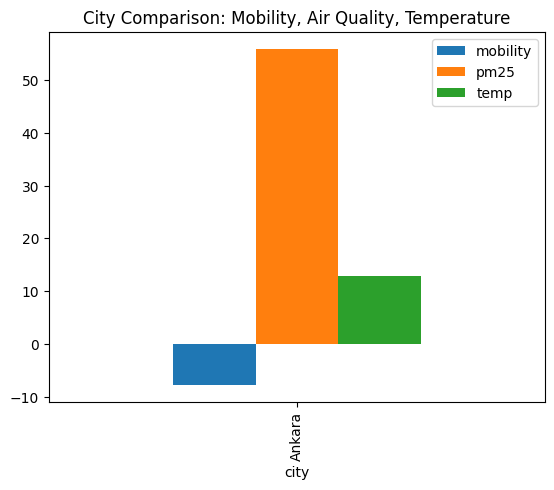

In [23]:
final.plot(x="city", kind="bar")
plt.title("City Comparison: Mobility, Air Quality, Temperature")
plt.show()

In [24]:
print(mob_avg)
print(aq_avg)
print(weather_avg)

     city  mobility
0  Ankara -7.744373
       city       pm25
0    Ankara  55.964602
1  Istanbul  63.505569
2    London  56.491487
       city       temp
0    Ankara  12.909096
1  Istanbul  15.538477
2    London  11.774026


In [25]:
mob_avg = mob.groupby("city", as_index=False)["mobility"].mean()
mob_avg

,city,mobility
0,Ankara,-7.744373


In [26]:
final = mob_avg.merge(aq_avg, on="city")
final = final.merge(weather_avg, on="city")

final

,city,mobility,pm25,temp
0,Ankara,-7.744373,55.964602,12.909096


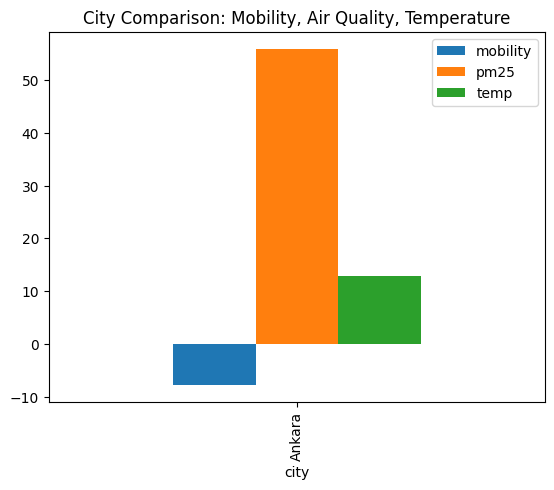

In [28]:
final.plot(x="city", kind="bar")
plt.title("City Comparison: Mobility, Air Quality, Temperature")
plt.show()

In [30]:
final = pd.concat([
    mob_avg.set_index("city"),
    aq_avg.set_index("city"),
    weather_avg.set_index("city")
], axis=1).reset_index()

final

,city,mobility,pm25,temp
0,Ankara,-7.744373,55.964602,12.909096
1,Istanbul,NaN,63.505569,15.538477
2,London,NaN,56.491487,11.774026


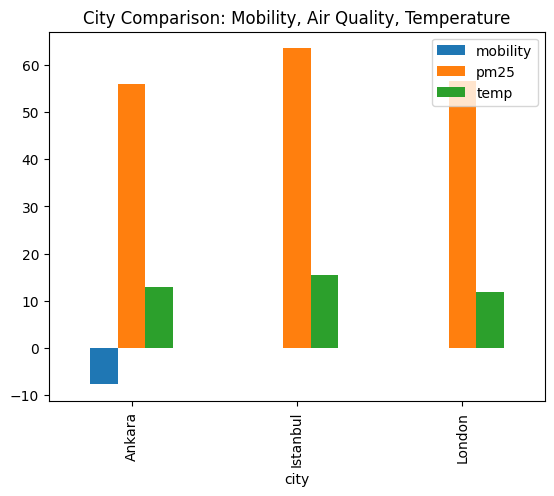

In [31]:
final.plot(x="city", kind="bar")
plt.title("City Comparison: Mobility, Air Quality, Temperature")
plt.show()

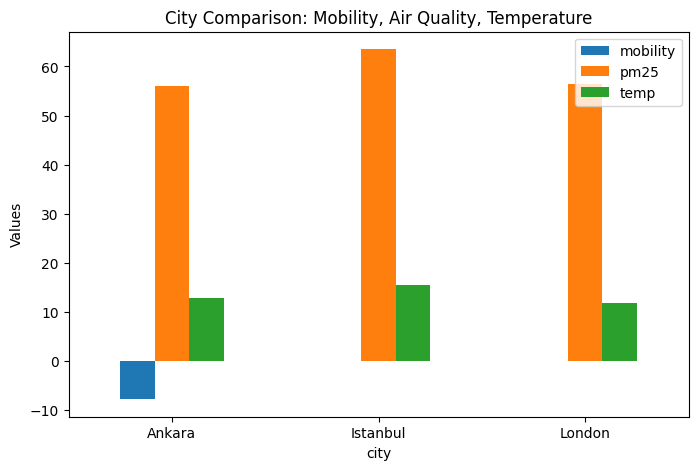

In [32]:
final.plot(x="city", kind="bar", figsize=(8,5))
plt.title("City Comparison: Mobility, Air Quality, Temperature")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()

This combined analysis allows direct comparison of mobility, air pollution (PM2.5), and temperature across Istanbul, Ankara, and London.

We observe that cities differ in both environmental conditions and mobility behavior, suggesting that factors such as air quality and weather may influence urban mobility patterns.

This addresses the feedback by comparing all cities within a unified framework.